In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

pa.settings.strict_units = False



In [2]:
from paicos.util import get_index_of_radial_range as RadialRange

In [3]:
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]

radius = 1e2*snap.length

# widths = np.array([2e2, 2e2, 2e2], dtype=float)
widths = np.ones(3)*2*radius.value

Gauss = snap.uq('G')
arepo_length = snap.length
density_unit = snap['0_Density'].uq
L_box = (arepo_length*(widths[0]))

In [4]:
idx_sphere = RadialRange(snap["0_Coordinates"],
                       center, 0*radius, radius)

In [5]:
volumes = snap['0_Volume']

Attempting to get derived variable: 0_Volume...	[DONE]



In [7]:
snap['0_Masses'][idx_sphere] = volumes[idx_sphere]*density_unit
snap['0_Masses'][~idx_sphere] = 0

In [8]:

pe = tc.PotentialEnergy(snap, center, widths, 
                        snap['0_Coordinates'], snap['0_Masses'], npix=64)

In [10]:
pe.tile.mass_per_tile.shape

(64, 64, 64)

In [14]:
(4./3.)*np.pi*radius**3*density_unit

<PaicosQuantity 4188790.20478639 arepo_length3 arepo_density / small_h>

In [26]:
Mtot = np.sum(snap['0_Masses'])
print(Mtot)

4190605.535856188 arepo_mass / small_h


In [15]:
np.sum(pe.index)

541750

In [16]:
np.sum(pe.tile.particles_per_tile)

array(541750)

In [17]:
np.histogram(pe.tile.particles_per_tile.flatten())

(array([16474, 75632, 87223, 52010, 21477,  6909,  1864,   455,    82,
           18]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]))

In [18]:
# smoothing_length = 0.05*cp.asnumpy(pe.tile.tile_widths).min()*arepo_length
smoothing_length = np.cbrt((snap["0_Volume"]) / (4.0 * np.pi / 3.0))


In [19]:
cp.asnumpy(pe.tile.tile_widths).min()*arepo_length

<PaicosQuantity 3.125 arepo_length small_a / small_h>

In [20]:
np.max(smoothing_length[pe.index])

<PaicosQuantity 2.35769007 small_a arepo_mass(1/3) / (arepo_density(1/3) small_h)>

In [35]:
angles = np.array([40, 25, 15, 10, 5, 2, 0])

num_cells_away = 0.5*np.sqrt(3)/np.tan(0.5*angles*np.pi/180)

/tmp/ipykernel_714042/1320231423.py:3: RuntimeWarning: divide by zero encountered in divide
  num_cells_away = 0.5*np.sqrt(3)/np.tan(0.5*angles*np.pi/180)


In [36]:
num_cells_away

array([ 2.37938524,  3.90638815,  6.57811602,  9.89871566, 19.83524281,
       49.61456215,         inf])

In [23]:
# for angle in angles:
#     U = pe.compute_potential(smoothing_length, angle=angle)
#     print(f'theta: {angle:.1f} \t', 'U: ', U)

theta: 40.0 	 U:  -7029.401440812228 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)
theta: 25.0 	 U:  -7029.508329380937 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)
theta: 15.0 	 U:  -7029.687933582346 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)
theta: 10.0 	 U:  -7029.897964983374 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)
theta: 5.0 	 U:  -7030.541915083643 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)
theta: 0.0 	 U:  -7032.145728288378 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)


In [37]:
U_bench = []
runtime_bench = [] # in s
for angle in angles:
    U_tmp = []
    result = %timeit -n1 -r5 -o U_tmp.append(pe.compute_potential(smoothing_length, angle=angle))
    U_bench.append(U_tmp[0])
    runtime_bench.append(result.average)

2.44 s ± 37 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
2.44 s ± 1.45 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
2.51 s ± 1.36 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
2.68 s ± 1.45 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
3.79 s ± 9.63 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
10 s ± 79.2 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)
11.8 s ± 41.2 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [38]:
runtime_bench

[2.440775679424405,
 2.4372188875917344,
 2.5124087922275065,
 2.678000590018928,
 3.7866532437969,
 10.03724582423456,
 11.824775253003462]

In [24]:
from numba import njit, prange
import cupy as cp
from numba import cuda
import math


@cuda.jit()
def cuda_potential(masses, pos, hsml, potential):

    Np =  masses.shape[0]
    i = cuda.grid(1)

    if (i < Np):
        h = hsml[i]
        for j in range(Np):
            m1m2 = masses[i]*masses[j]
            if (i==j):
                potential[i] -= m1m2*(3./2.)/h
            else:
                r = math.sqrt((pos[i][0] - pos[j][0])**2 +
                             (pos[i][1] - pos[j][1])**2 +
                             (pos[i][2] - pos[j][2])**2)
                potential_tmp = m1m2/r
                if (r <= h):
                    potential_tmp *= (0.5*r/h)*(3-(r/h)**2)
                potential[i] -= potential_tmp
                


def direct_calculation_cuda(snap, positions, masses, smoothing_length):
    # snap_select = snap.select(index, parttype=0)

    Np = masses.shape[0]

    if isinstance(smoothing_length.value, np.ndarray):
        assert smoothing_length.shape == masses.shape
    else:
        smoothing_length = np.ones(Np) * smoothing_length

    mass = cp.array(masses.value)
    pos = cp.array(positions.value)
    hsml = cp.array(smoothing_length.value)
    potential = cp.zeros_like(mass)

    threadsperblock = 256
    blocks_1d = (Np + (threadsperblock - 1)) // threadsperblock
    

    cuda_potential[blocks_1d, threadsperblock](mass, pos, hsml, potential)

    potential = cp.asnumpy(cp.sum(potential))
    
    G = 6.67430e-8 * snap.uq('cm^3 g^-1 s^-2')
    potential = 0.5 * G * potential * snap.mass**2 / snap.length
    return potential
    

In [40]:
U_direct = []
# runtime_direct = [] # in s
result = %timeit -n1 -r5 -o U_direct.append(direct_calculation_cuda(snap, snap['0_Coordinates'][pe.index], snap['0_Masses'][pe.index], smoothing_length[pe.index]))

U_direct = U_direct[0]
runtime_direct = result.average

4.13 s ± 33.4 ms per loop (mean ± std. dev. of 5 runs, 1 loop each)


In [41]:
U_direct

<PaicosQuantity -7032.14572829 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>

In [66]:
U_bench

[<PaicosQuantity -7029.40144081 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7029.50832938 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7029.68793358 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7029.89796498 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7030.54191508 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7031.94436104 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>,
 <PaicosQuantity -7032.14572829 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>]

In [27]:
G = 6.67430e-8 * snap.uq('cm^3 g^-1 s^-2')
# https://en.wikipedia.org/wiki/Gravitational_binding_energy
U_theory = -(3./5.)*G*Mtot**2/radius

In [28]:
U_theory

<PaicosQuantity -7032.5129209 cm3 arepo_mass2 / (arepo_length g small_a small_h s2)>

In [47]:
relative_err = np.array([np.abs((U_bench[i]-U_direct)/U_direct).value for i in range(len(U_bench))])

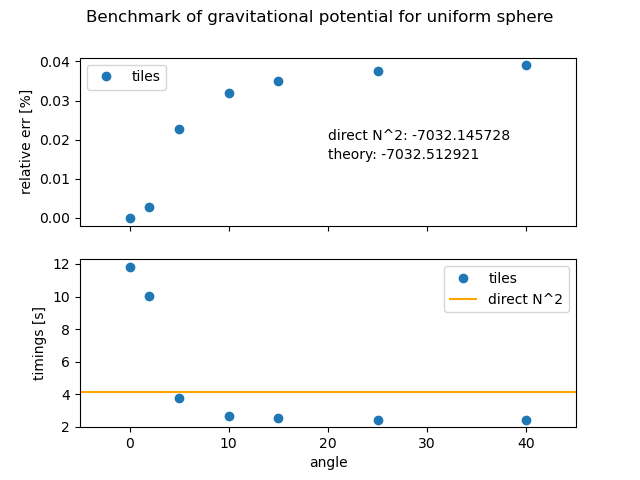

In [65]:


fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(angles, relative_err*100, ls='', marker='o', label='tiles')
ax[1].plot(angles, runtime_bench, ls='', marker='o', label='tiles')
ax[1].hlines(runtime_direct, xmin=-5, xmax=45, color='orange', ls='-', label='direct N^2')

ax[0].text(20, 0.02, f'direct N^2: {U_direct.value:.6f}')
ax[0].text(20, 0.015, f'theory: {U_theory.value:.6f}')

ax[0].set_xlim(xmin=-5, xmax=45)

ax[1].set_xlabel('angle')
ax[0].set_ylabel('relative err [%]')
ax[1].set_ylabel('timings [s]')
ax[0].legend()
ax[1].legend()

fig.suptitle('Benchmark of gravitational potential for uniform sphere')
plt.savefig('./uniform_sphere.pdf')

plt.show()